# Populations and devices

**What you'll learn / who it's for (simulation).** Scale from one neuron to *populations*: create groups of NEST-compatible neurons, combine and slice them with `NodeView` algebra, attach stimulation and recording devices, and read population spikes back as a raster and a firing rate.

Mirrors PyNEST Part 2 in the `brainpy.state` idiom.

In [1]:
import jax
jax.config.update('jax_enable_x64', True)
import brainstate
brainstate.environ.set(precision=64)

import numpy as np
import brainunit as u
import braintools
import matplotlib.pyplot as plt
from brainpy import state as bp

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## Creating a population

`sim.create(model, N, ...)` makes a population of `N` neurons and returns a `NodeView`. Parameters use NEST's names and units; for a large set, pass a `params=dict(...)` mapping. Here we build an excitatory and an inhibitory population of current-based IAF neurons.

In [2]:
npar = dict(C_m=250. * u.pF, tau_m=20. * u.ms, t_ref=2. * u.ms,
            E_L=0. * u.mV, V_reset=0. * u.mV, V_th=20. * u.mV,
            V_initializer=braintools.init.Constant(0. * u.mV))

sim = bp.Simulator(dt=0.1 * u.ms)
ne = sim.create(bp.iaf_psc_alpha, 80, params=npar)    # excitatory
ni = sim.create(bp.iaf_psc_alpha, 20, params=npar)    # inhibitory
print('ne:', ne, '\nni:', ni)

ne: <brainpy.state.NodeView object at 0x7f57b582fe00> 
ni: <brainpy.state.NodeView object at 0x7f57b59cf750>


## `NodeView` algebra: combine and slice

Two operators let a single `connect` target a combined or partial population:

- **concatenate** — `ne + ni` is the whole network (E then I),
- **slice** — `ne[:10]` is the first 10 excitatory neurons.

We drive both populations with a shared Poisson background (`all_to_all`) and record a sub-sample of each.

In [3]:
noise = sim.create(bp.poisson_generator, rate=8000. * u.Hz, rng_seed=0)
esr = sim.create(bp.spike_recorder)
isr = sim.create(bp.spike_recorder)

sim.connect(noise, ne + ni, weight=10. * u.pA, delay=1.5 * u.ms, rule=bp.all_to_all)
sim.connect(ne[:10], esr)            # record the first 10 excitatory
sim.connect(ni[:10], isr)            # record the first 10 inhibitory

res = sim.simulate(500. * u.ms)

## Reading population output: rate and raster

`res.rate(view)` gives the mean firing rate (Hz) and `res.spikes(view)` gives the per-step spike matrix `(T, N)` we can scatter into a raster.

exc rate: 51.20 spks/s
inh rate: 50.20 spks/s


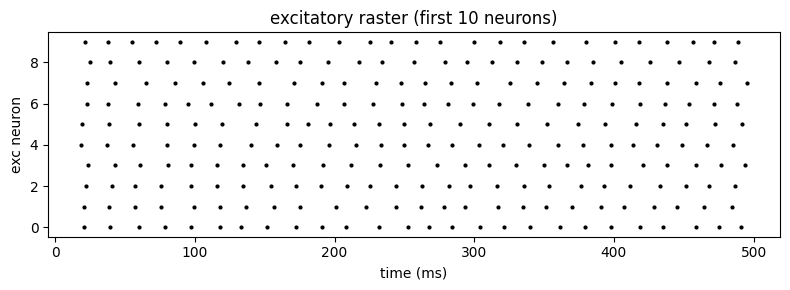

In [4]:
print(f'exc rate: {res.rate(esr):.2f} spks/s')
print(f'inh rate: {res.rate(isr):.2f} spks/s')

spk = np.asarray(res.spikes(esr))           # (T, 10)
ts, ids = np.nonzero(spk > 0)
t_ms = np.asarray(u.get_mantissa(res.times / u.ms))
plt.figure(figsize=(8, 3))
plt.scatter(t_ms[ts], ids, s=4, color='k')
plt.xlabel('time (ms)'); plt.ylabel('exc neuron')
plt.title('excitatory raster (first 10 neurons)')
plt.tight_layout()

## See also

- [One neuron](01-one-neuron.ipynb) — the single-neuron starting point.
- [Connect a network](03-connect-network.ipynb) — recurrent wiring rules.
- [Connectivity](../connectivity.rst) — `NodeView` algebra and rules.
- [Devices](../devices.rst) — the full device catalog.